# Replication Notebook — RepMobile (WISDM-first)


## Paper Facts and Code Availability
- Paper DOI: https://doi.org/10.1109/JSEN.2024.3424578
- Official repo: https://github.com/Yuki0614/RepMobile
- Original protocol summary: structural reparameterization with folded inference graph.

## WISDM Adaptation
- Active config: `configs/papers/repmobile_wisdm.yaml`
- This notebook runs WISDM-first adaptation while preserving paper architecture intent.


## Notebook Contract
- Runtime / dependency guard
- Paper facts + code availability
- WISDM adaptation section
- FP32 training/eval on `random_stratified` + `user_holdout`
- PTQ INT8 + QAT INT8 exports
- FP32 float `.tflite` export for size tracking (`fp32_model_size_kb`)
- Strict deploy-gate summary (`full_integer_io`, `tflm_compatible`, unsupported ops)
- Per-paper CSV/MD + master results append


## Compression Scope Note
- KD-related methodology from papers is documented for reproducibility context only.
- Notebook execution enforces PTQ/QAT compression flow only (`experiment.compression_focus=ptq_qat_only`).
- This notebook uses a Conv2D-equivalent architecture for QAT compatibility; Conv1D paper operators are preserved semantically via `(k)->(k,1)` mapping.


In [1]:
from pathlib import Path
import sys
import os
import json
import importlib
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

# Optional safeguard: disable GPU if kernel is unstable on CUDA runtime.
USE_GPU = True
if not USE_GPU:
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Ensure repo root is importable when launched from different working directories.
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    for parent in [REPO_ROOT, *REPO_ROOT.parents]:
        if (parent / "src").exists():
            REPO_ROOT = parent
            break
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

required_modules = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "IPython": "ipython",
    "yaml": "PyYAML",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow",
    "tensorflow_model_optimization": "tensorflow-model-optimization",
}
missing = [
    f"{mod} (pip package: {pkg})"
    for mod, pkg in required_modules.items()
    if importlib.util.find_spec(mod) is None
]
if missing:
    missing_text = "\n- ".join(missing)
    raise ModuleNotFoundError(
        "Missing required notebook dependencies:\n- "
        + missing_text
        + "\n\nActivate tinymlproj and install dependencies:\n"
        + "conda activate tinymlproj && conda env update -n tinymlproj -f environment.yml --prune"
    )

import tensorflow as tf
print("TF version:", tf.__version__)
print("Visible GPUs:", tf.config.list_physical_devices("GPU"))

# Fail fast if local file is stale (pre-FP32-TFLite-size patch).
_rpe_file = REPO_ROOT / "src/run_paper_experiment.py"
if _rpe_file.exists():
    _rpe_src = _rpe_file.read_text(encoding="utf-8")
    if "from src.utils.artifacts import model_fp32_tflite_path" in _rpe_src:
        raise RuntimeError(
            "Outdated src/run_paper_experiment.py detected in workspace. "
            "Please refresh repo files and rerun from the first cell."
        )

importlib.invalidate_caches()
for _stale_mod in ("src.run_paper_experiment",):
    sys.modules.pop(_stale_mod, None)

AUTO_RELOAD_PROJECT_MODULES = True
if AUTO_RELOAD_PROJECT_MODULES:
    for _mod_name in (
        "src.models.xtinyhar_student_tf",
        "src.models.repmobile_folded_tf",
        "src.models.tcn_attention_har_tf",
        "src.models.daghero_cnn_searchspace_tf",
        "src.models.tcn_inception_tf",
        "src.models.serialization",
        "src.eval.evaluate_model",
        "src.quant.ptq_full_int8",
        "src.quant.qat_train",
        "src.utils.artifacts",
        "src.eval.notebook_reporting",
        "src.run_paper_experiment",
    ):
        if _mod_name in sys.modules:
            importlib.reload(sys.modules[_mod_name])

import src.run_paper_experiment as _run_mod
run_paper_experiment = _run_mod.run_paper_experiment

from src.utils.config import load_yaml
from src.utils.device_runtime import runtime_device_report
from src.eval.evaluate_model import evaluate_model_for_protocol
from src.utils.artifacts import model_ckpt_path, split_npz_path

if "load_checkpoint_model" not in evaluate_model_for_protocol.__code__.co_names:
    raise RuntimeError(
        "Stale evaluate_model module detected (safe loader missing). "
        "Restart kernel and rerun from the first cell."
    )

RUN_MODE = "sanity_check"  # switch to "full_run" for full-length runs (GPU-first, CPU fallback enabled)
CONFIG_PATH = REPO_ROOT / 'configs/papers/repmobile_wisdm.yaml'
assert CONFIG_PATH.exists(), f"Missing config: {CONFIG_PATH}"
cfg = load_yaml(CONFIG_PATH)
cfg.setdefault("runtime", {})["run_mode"] = RUN_MODE
cfg.setdefault("experiment", {})["compression_focus"] = "ptq_qat_only"
runtime = runtime_device_report(cfg)

print("repo_root:", REPO_ROOT)
print("paper_slug:", cfg.get("experiment", {}).get("paper_slug"))
print("model_variant:", cfg.get("experiment", {}).get("model_variant"))
is_conv2d_variant = str(cfg.get("experiment", {}).get("model_variant", "")).endswith("_conv2d")
print("conv2d_qat_safe_variant:", is_conv2d_variant)
print("[NOTE] Conv1D paper ops are executed via Conv2D-equivalent mapping (k)->(k,1) for QAT compatibility.")
if not is_conv2d_variant:
    print("[WARN] Active model_variant is not *_conv2d; QAT may fail on Conv1D/SeparableConv1D in tfmot 0.8.")
print("window_size:", cfg.get("paper_protocol", {}).get("wisdm_window_override"))
print("run_mode:", runtime["run_mode"])
print("detected_gpus:", runtime["gpus"])
print("stage_device_map:", runtime["resolved_stage_devices"])
print("[NOTE] Auto-reload is ON to prevent stale module paths in notebook runtime.")

strict_gate_cfg = {
    "ptq_strict_full_int8": bool(cfg.get("quant", {}).get("ptq", {}).get("strict_full_int8", True)),
    "ptq_require_tflm_compatible": bool(cfg.get("quant", {}).get("ptq", {}).get("require_tflm_compatible", True)),
    "ptq_accepted_integer_io_dtypes": cfg.get("quant", {}).get("ptq", {}).get("accepted_integer_io_dtypes", ["int8", "uint8"]),
    "qat_strict_full_int8": bool(cfg.get("quant", {}).get("qat", {}).get("strict_full_int8", True)),
    "qat_require_tflm_compatible": bool(cfg.get("quant", {}).get("qat", {}).get("require_tflm_compatible", True)),
    "qat_accepted_integer_io_dtypes": cfg.get("quant", {}).get("qat", {}).get("accepted_integer_io_dtypes", ["int8", "uint8"]),
    "deploy_allowed_ops_profile": cfg.get("deploy", {}).get("allowed_ops_profile", "default"),
    "deploy_allowed_ops_override": cfg.get("deploy", {}).get("allowed_ops"),
}
print("strict_gate_cfg:", strict_gate_cfg)


2026-03-05 02:09:47.636928: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-05 02:09:47.636978: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-05 02:09:47.637015: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-05 02:09:47.645236: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.14.1
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-03-05 02:09:48.852890: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-05 02:09:48.860147: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-05 02:09:48.860192: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.


repo_root: /home/dellio/github/har-mcu
paper_slug: repmobile
model_variant: repmobile_folded_conv2d
conv2d_qat_safe_variant: True
[NOTE] Conv1D paper ops are executed via Conv2D-equivalent mapping (k)->(k,1) for QAT compatibility.
window_size: 200
run_mode: sanity_check
detected_gpus: ['/physical_device:GPU:0']
stage_device_map: {'train': 'gpu', 'eval_fp32': 'gpu', 'ptq': 'gpu', 'eval_ptq': 'gpu', 'qat': 'gpu', 'eval_qat': 'gpu'}
[NOTE] Auto-reload is ON to prevent stale module paths in notebook runtime.
strict_gate_cfg: {'ptq_strict_full_int8': True, 'ptq_require_tflm_compatible': True, 'ptq_accepted_integer_io_dtypes': ['int8', 'uint8'], 'qat_strict_full_int8': True, 'qat_require_tflm_compatible': True, 'qat_accepted_integer_io_dtypes': ['int8', 'uint8'], 'deploy_allowed_ops_profile': 'nano33ble_extended', 'deploy_allowed_ops_override': None}


In [2]:
# Run FP32 + PTQ + QAT + standardized reporting
out = run_paper_experiment(cfg)
out


2026-03-05 02:09:49.223021: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-05 02:09:49.223103: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-05 02:09:49.223140: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-05 02:09:49.440792: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-05 02:09:49.440858: I tensorflow/compile

Epoch 1/40


2026-03-05 02:10:07.433139: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inrepmobile_folded_conv2d/repblock_0_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-03-05 02:10:07.678916: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2026-03-05 02:10:08.606860: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x64afae80fab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-05 02:10:08.606905: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-03-05 02:10:08.706816: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


42/42 - 4s - loss: 1.6602 - accuracy: 0.2759 - val_loss: 1.7835 - val_accuracy: 0.3149 - lr: 1.0000e-04 - 4s/epoch - 83ms/step
Epoch 2/40
42/42 - 0s - loss: 1.5329 - accuracy: 0.3713 - val_loss: 1.7725 - val_accuracy: 0.3149 - lr: 1.0000e-04 - 425ms/epoch - 10ms/step
Epoch 3/40
42/42 - 0s - loss: 1.4295 - accuracy: 0.4800 - val_loss: 1.7606 - val_accuracy: 0.3149 - lr: 1.0000e-04 - 415ms/epoch - 10ms/step
Epoch 4/40
42/42 - 0s - loss: 1.3449 - accuracy: 0.5862 - val_loss: 1.7476 - val_accuracy: 0.3149 - lr: 1.0000e-04 - 414ms/epoch - 10ms/step
Epoch 5/40
42/42 - 0s - loss: 1.2837 - accuracy: 0.6416 - val_loss: 1.7338 - val_accuracy: 0.4069 - lr: 1.0000e-04 - 434ms/epoch - 10ms/step
Epoch 6/40
42/42 - 0s - loss: 1.2356 - accuracy: 0.6618 - val_loss: 1.7187 - val_accuracy: 0.4084 - lr: 1.0000e-04 - 411ms/epoch - 10ms/step
Epoch 7/40
42/42 - 0s - loss: 1.1897 - accuracy: 0.6740 - val_loss: 1.7012 - val_accuracy: 0.4091 - lr: 1.0000e-04 - 410ms/epoch - 10ms/step
Epoch 8/40
42/42 - 0s - los

INFO:tensorflow:Assets written to: /tmp/tmpuuiztnuy/assets
2026-03-05 02:10:28.768736: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-05 02:10:28.768777: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-05 02:10:28.769325: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpuuiztnuy
2026-03-05 02:10:28.773925: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-05 02:10:28.773941: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpuuiztnuy
2026-03-05 02:10:28.784996: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-03-05 02:10:28.786100: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-03-05 02:10:28.817460: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

...

Epoch 1/8


2026-03-05 02:11:25.041500: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inrepmobile_folded_conv2d/quant_repblock_0_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


42/42 - 4s - loss: 0.7193 - accuracy: 0.7982 - val_loss: 0.7712 - val_accuracy: 0.7301 - 4s/epoch - 96ms/step
Epoch 2/8
42/42 - 2s - loss: 0.6707 - accuracy: 0.8062 - val_loss: 0.7431 - val_accuracy: 0.7362 - 2s/epoch - 48ms/step
Epoch 3/8
42/42 - 2s - loss: 0.6273 - accuracy: 0.8178 - val_loss: 0.7177 - val_accuracy: 0.7500 - 2s/epoch - 50ms/step
Epoch 4/8
42/42 - 2s - loss: 0.5942 - accuracy: 0.8227 - val_loss: 0.7005 - val_accuracy: 0.7485 - 2s/epoch - 52ms/step
Epoch 5/8
42/42 - 2s - loss: 0.5657 - accuracy: 0.8225 - val_loss: 0.7014 - val_accuracy: 0.7385 - 2s/epoch - 50ms/step
Epoch 6/8
42/42 - 2s - loss: 0.5449 - accuracy: 0.8263 - val_loss: 0.6949 - val_accuracy: 0.7401 - 2s/epoch - 49ms/step
Epoch 7/8
42/42 - 2s - loss: 0.5199 - accuracy: 0.8288 - val_loss: 0.6975 - val_accuracy: 0.7339 - 2s/epoch - 52ms/step
Epoch 8/8
42/42 - 2s - loss: 0.4997 - accuracy: 0.8292 - val_loss: 0.6866 - val_accuracy: 0.7362 - 2s/epoch - 47ms/step
INFO:tensorflow:Assets written to: /tmp/tmprsu4voo

INFO:tensorflow:Assets written to: /tmp/tmprsu4voom/assets
/home/dellio/anaconda3/envs/tinymlproj/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-05 02:11:46.074946: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-05 02:11:46.074987: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-05 02:11:46.075113: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmprsu4voom
2026-03-05 02:11:46.081479: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-05 02:11:46.081495: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmprsu4voom
2026-03-05 02:11:46.096383: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
202

{'paper_slug': 'repmobile',
 'rows': [{'paper_slug': 'repmobile',
   'protocol': 'random_stratified',
   'variant': 'repmobile_folded_conv2d',
   'run_id': 'wisdm_r0',
   'window_size': 200,
   'seed': 42,
   'compression_focus': 'ptq_qat_only',
   'run_mode': 'sanity_check',
   'train_device': 'gpu',
   'eval_fp32_device': 'gpu',
   'ptq_device': 'gpu',
   'eval_ptq_device': 'gpu',
   'qat_device': 'gpu',
   'eval_qat_device': 'gpu',
   'fp32_training_time_sec': 19.76040043499961,
   'fp32_model_size_kb': 94.68359375,
   'fp32_tflite_model': '/home/dellio/github/har-mcu/models_tflite/repmobile_folded_conv2d_T200_Prandom_stratified_wisdm_r0_fp32.tflite',
   'fp32_tflite_status': 'ok',
   'fp32_tflite_error': None,
   'qat_training_time_sec': 18.618353685999864,
   'accuracy': 0.7715674362089915,
   'macro_f1': 0.577059167353506,
   'ptq_status': 'ok',
   'qat_status': 'ok',
   'ptq_allowed_ops_profile': 'micro_mutable_main',
   'qat_allowed_ops_profile': 'micro_mutable_main',
   'ptq_a

,paper_slug,protocol,variant,run_id,window_size,seed,compression_focus,run_mode,train_device,eval_fp32_device,...,deploy_gate,paper_target_score,delta_vs_paper,notes_assumptions,fp32_metrics_json,ptq_metrics_json,qat_metrics_json,ptq_report_json,qat_report_json,run_artifact_json
0,repmobile,random_stratified,repmobile_folded_conv2d,wisdm_r0,200,42,ptq_qat_only,sanity_check,gpu,gpu,...,"{'ptq': {'status': 'ok', 'full_integer_io': Tr...",None,None,None,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...
1,repmobile,user_holdout,repmobile_folded_conv2d,wisdm_r0,200,42,ptq_qat_only,sanity_check,gpu,gpu,...,"{'ptq': {'status': 'ok', 'full_integer_io': Tr...",None,None,None,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...


,protocol,fp32_model_size_kb,ptq_model_size_kb,qat_model_size_kb,fp32_tflite_status,fp32_tflite_model
0,random_stratified,94.68 KB,43.41 KB,46.91 KB,ok,/home/dellio/github/har-mcu/models_tflite/repmobile_folded_conv2d_T200_Prandom_stratified_wisdm_r0_fp32.tflite
1,user_holdout,94.68 KB,43.41 KB,46.91 KB,ok,/home/dellio/github/har-mcu/models_tflite/repmobile_folded_conv2d_T200_Puser_holdout_wisdm_r0_fp32.tflite


Note: fp32_model_size_kb is measured from exported float .tflite per protocol.

PTQ operator visibility (per protocol):
- interpreter_ops: delegate-free runtime ops from PTQ TFLite evaluation metrics
- tflm_ops: flatbuffer ops used by strict deploy-gate compatibility check

[random_stratified]
  interpreter_ops (9): ['CONV_2D', 'DEPTHWISE_CONV_2D', 'FULLY_CONNECTED', 'MEAN', 'PACK', 'RESHAPE', 'SHAPE', 'SOFTMAX', 'STRIDED_SLICE']
  tflm_ops       (9): ['CONV_2D', 'DEPTHWISE_CONV_2D', 'FULLY_CONNECTED', 'MEAN', 'PACK', 'RESHAPE', 'SHAPE', 'SOFTMAX', 'STRIDED_SLICE']

[user_holdout]
  interpreter_ops (9): ['CONV_2D', 'DEPTHWISE_CONV_2D', 'FULLY_CONNECTED', 'MEAN', 'PACK', 'RESHAPE', 'SHAPE', 'SOFTMAX', 'STRIDED_SLICE']
  tflm_ops       (9): ['CONV_2D', 'DEPTHWISE_CONV_2D', 'FULLY_CONNECTED', 'MEAN', 'PACK', 'RESHAPE', 'SHAPE', 'SOFTMAX', 'STRIDED_SLICE']

Strict deploy-gate status summary:
[random_stratified] ptq_status=ok | qat_status=ok
[user_holdout] ptq_status=ok | qat_status=ok

Str

,protocol,tier,status,full_integer_io,tflm_compatible,allowed_ops_profile,compatibility_scope,unsupported_ops_micro_mutable,possibly_supported_upstream_tflm,unsupported_in_reference,error
0,random_stratified,PTQ,ok,True,True,micro_mutable_main,micro_mutable_main,—,—,—,—
1,random_stratified,QAT,ok,True,True,micro_mutable_main,micro_mutable_main,—,—,—,—
2,user_holdout,PTQ,ok,True,True,micro_mutable_main,micro_mutable_main,—,—,—,—
3,user_holdout,QAT,ok,True,True,micro_mutable_main,micro_mutable_main,—,—,—,—


Note: if you changed model_variant/run_id, compare only current run rows and artifacts. Older files may still exist under reports/<paper_slug>/.


/home/dellio/github/har-mcu/src/eval/notebook_reporting.py:410: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  comparison_df.style.format(


,pipeline,protocol,model,accuracy,macro_f1,model_size_kb,training_time_sec,inference_latency_ms_median,inference_latency_ms_p95,status,ptq_status,qat_status,paper_target_accuracy,acc_delta_vs_target
0,WISDM replication,random_stratified,baseline float,0.7716,0.5771,94.68,19.76s,—,—,ok,ok,ok,None,—
1,WISDM replication,random_stratified,PTQ int8,0.7688,0.5745,43.41,—,0.413ms,0.481ms,ok,ok,None,None,—
2,WISDM replication,random_stratified,QAT int8,0.8074,0.6037,46.91,18.62s,0.528ms,0.548ms,ok,None,ok,None,—
3,WISDM replication,user_holdout,baseline float,0.7372,0.5324,94.68,17.63s,—,—,ok,ok,ok,None,—
4,WISDM replication,user_holdout,PTQ int8,0.7284,0.5315,43.41,—,0.416ms,0.466ms,ok,ok,None,None,—
5,WISDM replication,user_holdout,QAT int8,0.7622,0.5157,46.91,18.73s,0.545ms,0.596ms,ok,None,ok,None,—
6,paper target,—,baseline float,—,—,—,—,—,—,reference,None,None,None,—
7,paper target,—,PTQ int8,—,—,—,—,—,—,reference,None,None,None,—
8,paper target,—,QAT int8,—,—,—,—,—,—,reference,None,None,None,—


Note: Paper-target QAT may be unavailable in source papers; QAT rows here are replication extensions where target is N/A.


/home/dellio/github/har-mcu/src/eval/notebook_reporting.py:281: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


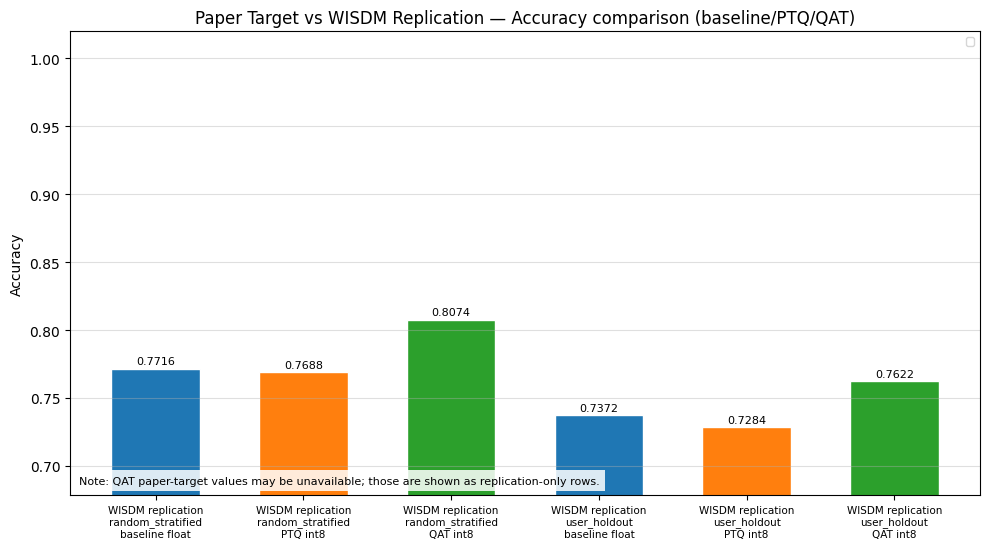

,pipeline,protocol,model,model_size_kb
0,WISDM replication,random_stratified,baseline float,94.68 KB
1,WISDM replication,random_stratified,PTQ int8,43.41 KB
2,WISDM replication,random_stratified,QAT int8,46.91 KB
3,WISDM replication,user_holdout,baseline float,94.68 KB
4,WISDM replication,user_holdout,PTQ int8,43.41 KB
5,WISDM replication,user_holdout,QAT int8,46.91 KB


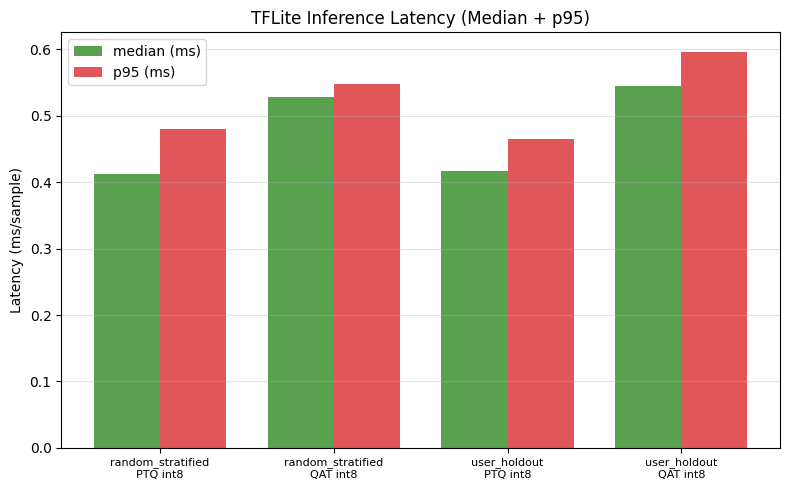


Reproducibility drift — WISDM replication (repeat evaluation on saved checkpoint):


/home/dellio/github/har-mcu/src/eval/notebook_reporting.py:439: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  reproducibility_df[


,protocol,split_hash,baseline_acc_first,baseline_acc_repeat,abs_drift,status
0,random_stratified,68c9e31789bca103,0.7716,0.7716,0.00e+00,PASS
1,user_holdout,2498bff9ddcfc589,0.7372,0.7372,0.00e+00,PASS


### Protocol: `random_stratified`

**FP32 training curve**

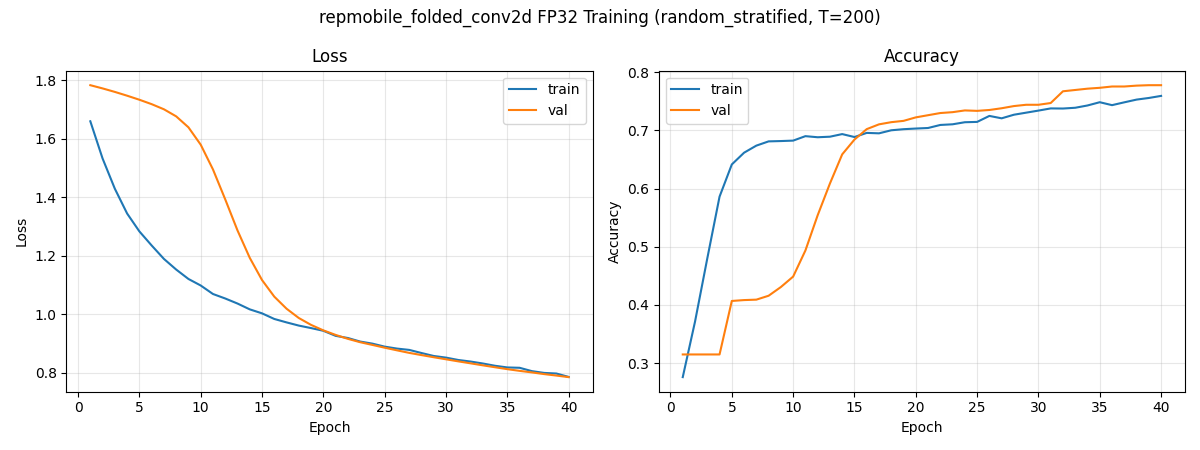

**QAT training curve**

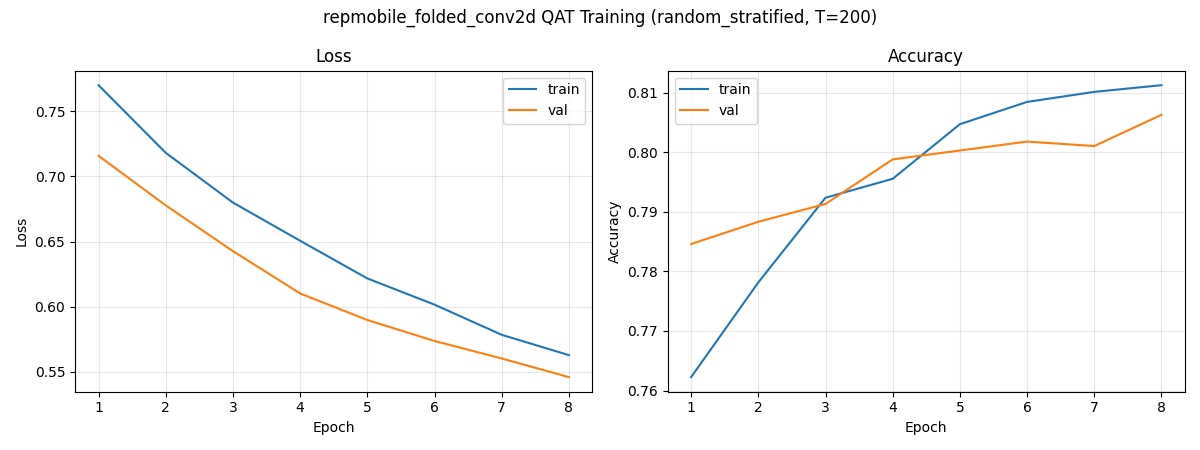

**FP32 confusion**

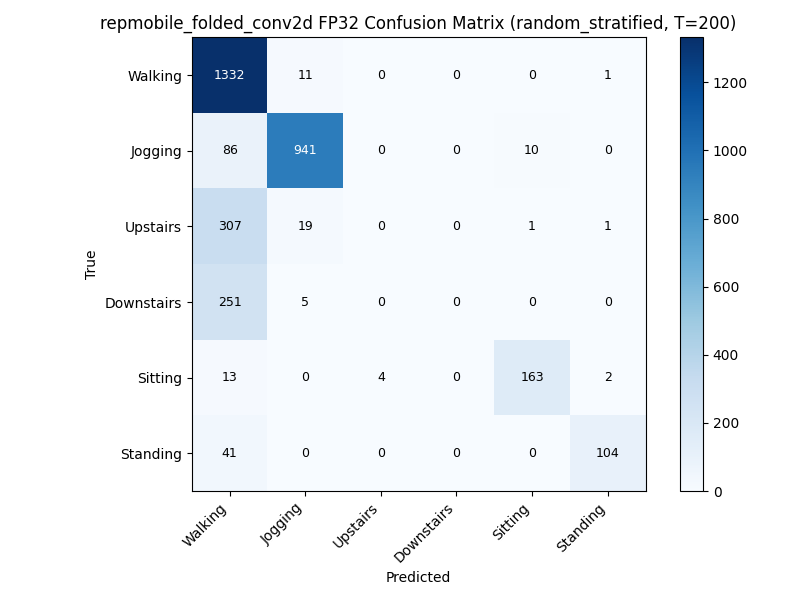

**PTQ confusion**

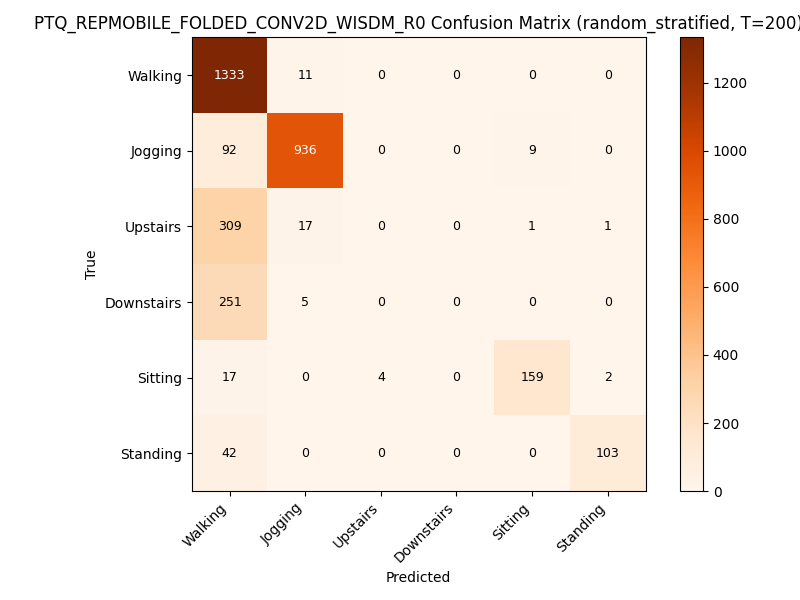

**QAT confusion**

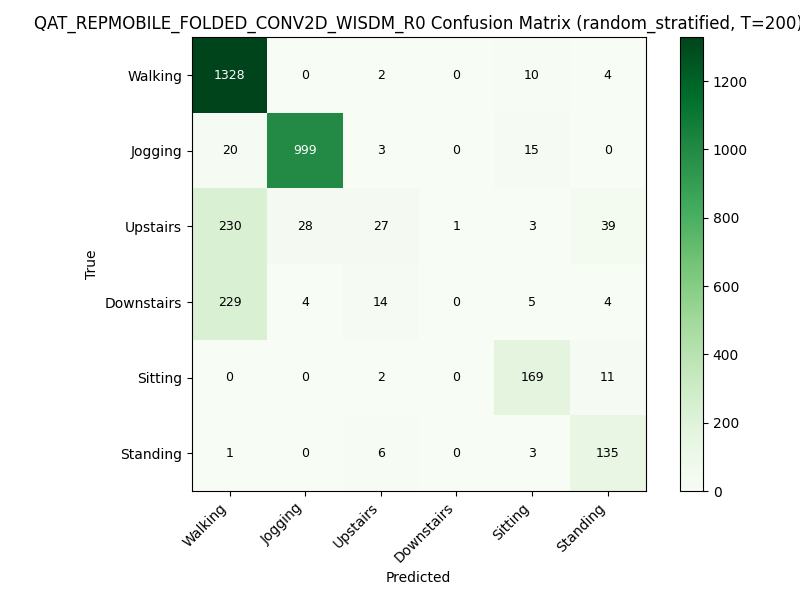

### Protocol: `user_holdout`

**FP32 training curve**

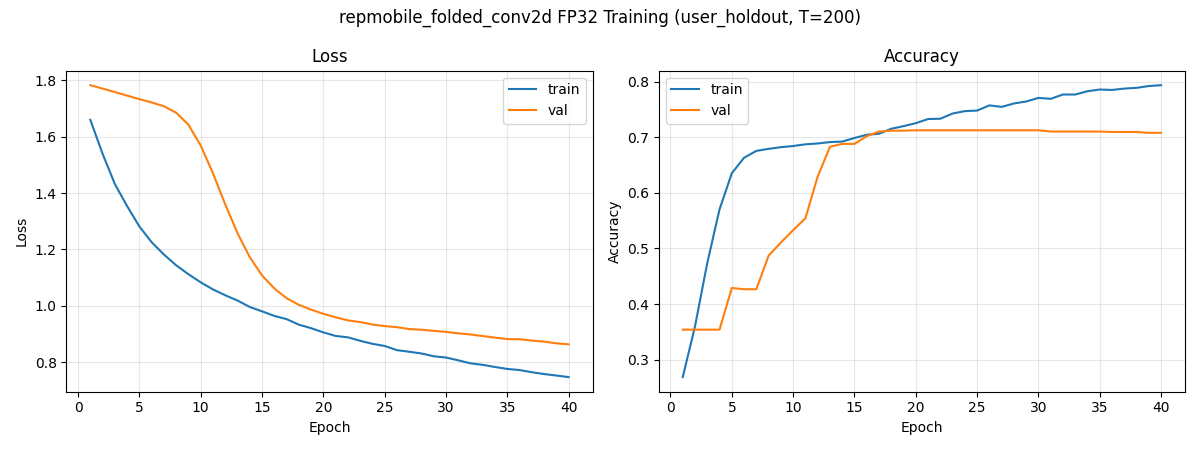

**QAT training curve**

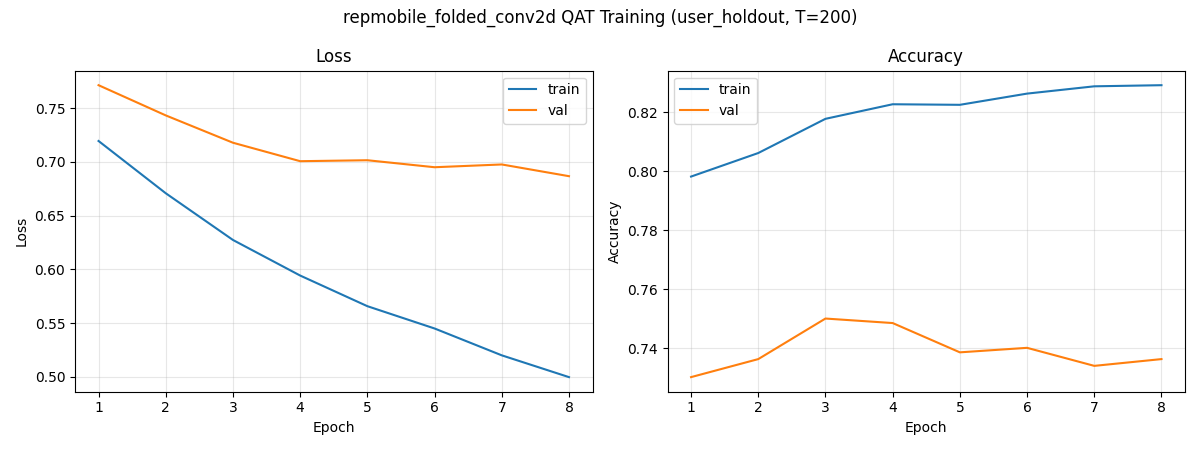

**FP32 confusion**

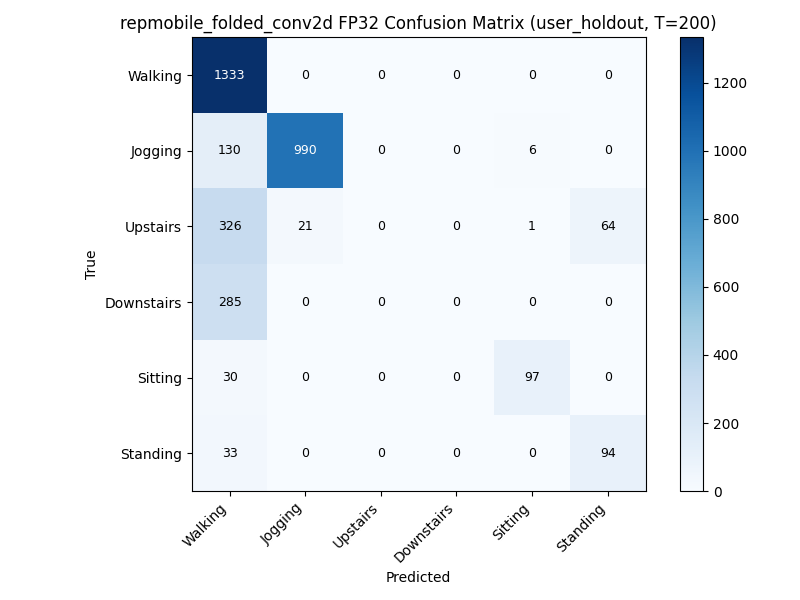

**PTQ confusion**

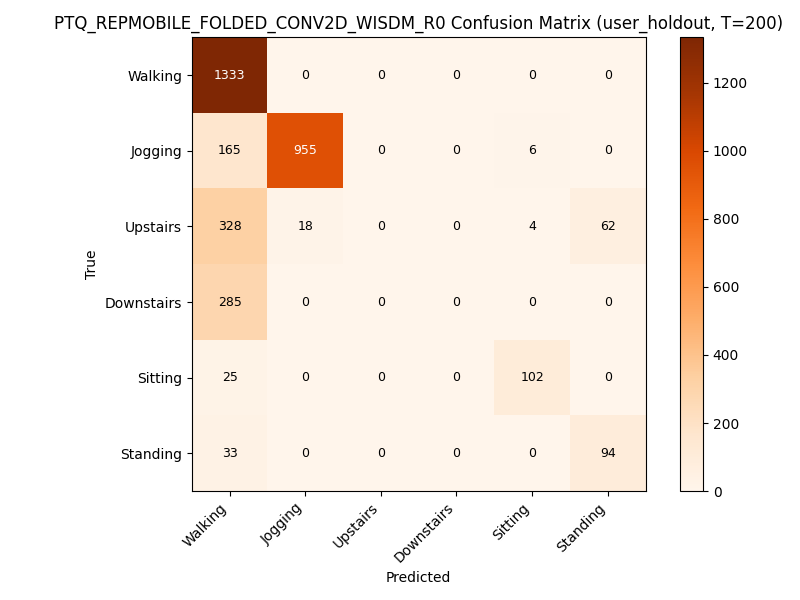

**QAT confusion**

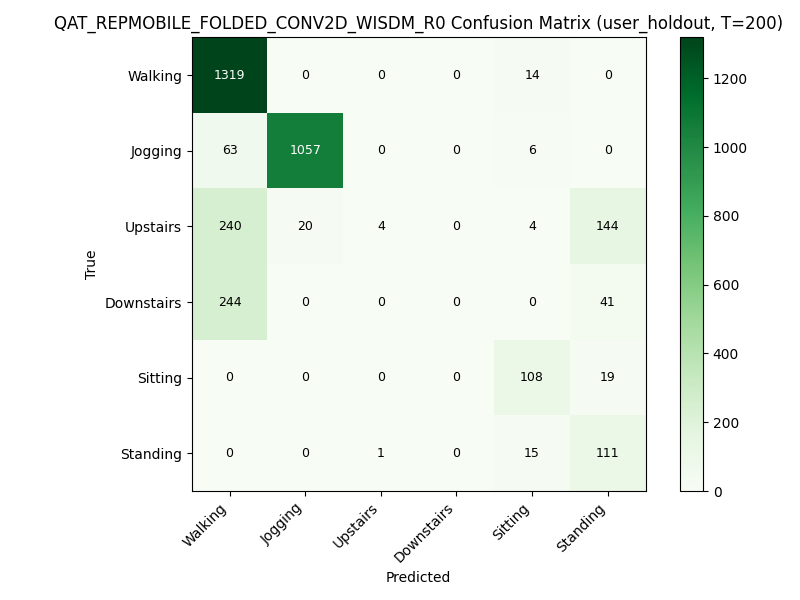

### Classification Report Snippets — `random_stratified`

FP32: macro_f1=0.577059167353506, weighted_f1=0.7036956203724145
PTQ: macro_f1=0.5744658932531931, weighted_f1=0.7014606510848906
QAT: macro_f1=0.6037255503044259, weighted_f1=0.7459164743892159


### Classification Report Snippets — `user_holdout`

FP32: macro_f1=0.5323846994461402, weighted_f1=0.6621268572236718
PTQ: macro_f1=0.5315173051412764, weighted_f1=0.6545941789546581
QAT: macro_f1=0.5156669176716828, weighted_f1=0.6896052184105866


## Saved Comparison CSV Snapshot

,pipeline,protocol,model,accuracy,macro_f1,model_size_kb,training_time_sec,inference_latency_ms_median,inference_latency_ms_p95,status,ptq_status,qat_status,paper_target_accuracy,acc_delta_vs_target
0,WISDM replication,random_stratified,baseline float,0.771567,0.577059,94.683594,19.760400,NaN,NaN,ok,ok,ok,NaN,NaN
1,WISDM replication,random_stratified,PTQ int8,0.768834,0.574466,43.414062,NaN,0.412646,0.480816,ok,ok,NaN,NaN,NaN
2,WISDM replication,random_stratified,QAT int8,0.807412,0.603726,46.914062,18.618354,0.528305,0.547658,ok,NaN,ok,NaN,NaN
3,WISDM replication,user_holdout,baseline float,0.737243,0.532385,94.683594,17.628862,NaN,NaN,ok,ok,ok,NaN,NaN
4,WISDM replication,user_holdout,PTQ int8,0.728446,0.531517,43.414062,NaN,0.416201,0.465746,ok,ok,NaN,NaN,NaN
5,WISDM replication,user_holdout,QAT int8,0.762170,0.515667,46.914062,18.730121,0.544620,0.596000,ok,NaN,ok,NaN,NaN
6,paper target,—,baseline float,NaN,NaN,NaN,NaN,NaN,NaN,reference,NaN,NaN,NaN,NaN
7,paper target,—,PTQ int8,NaN,NaN,NaN,NaN,NaN,NaN,reference,NaN,NaN,NaN,NaN
8,paper target,—,QAT int8,NaN,NaN,NaN,NaN,NaN,NaN,reference,NaN,NaN,NaN,NaN


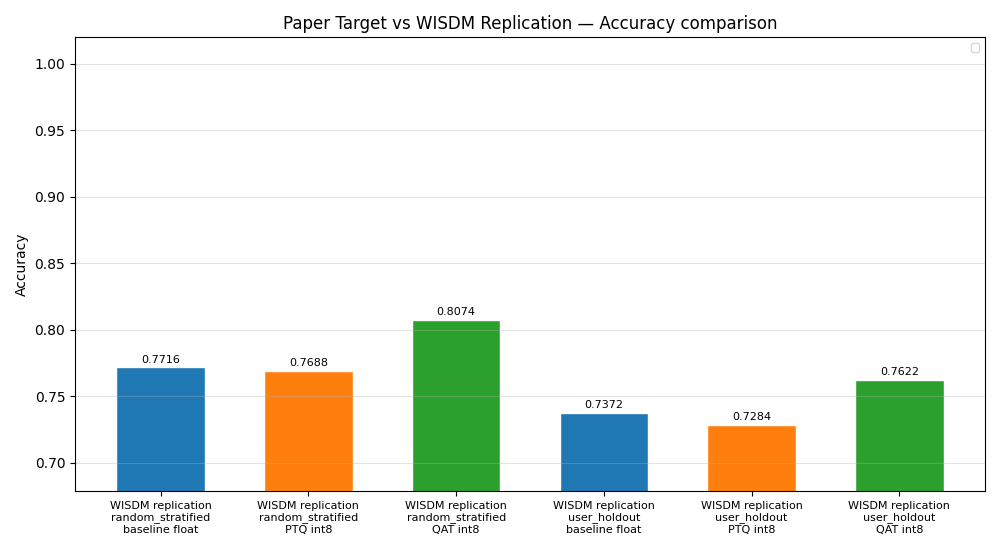

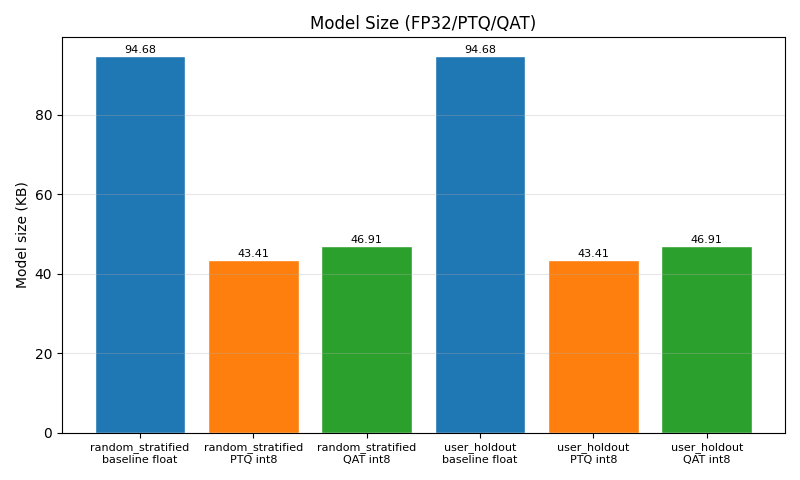

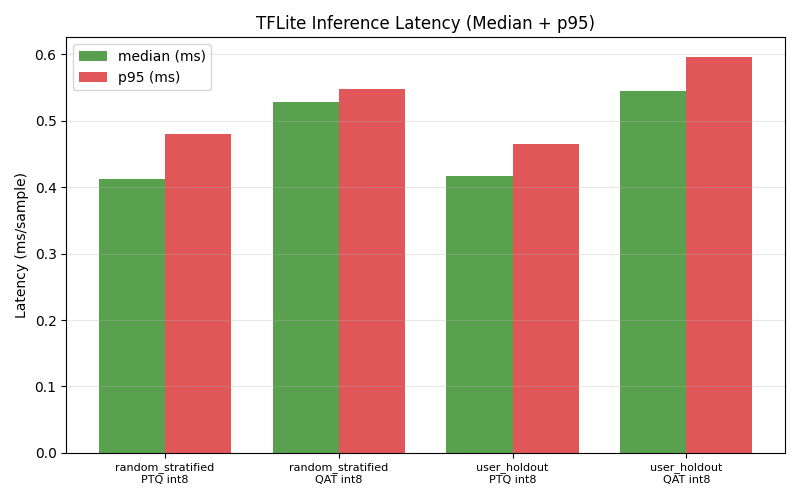

## Master Results Snapshot

,paper_slug,protocol,variant,run_id,window_size,seed,compression_focus,run_mode,train_device,eval_fp32_device,...,qat_metrics_json,ptq_report_json,qat_report_json,run_artifact_json,ptq_allowed_ops_profile,qat_allowed_ops_profile,fp32_model_size_kb,fp32_tflite_model,fp32_tflite_status,fp32_tflite_error
2,repmobile,random_stratified,repmobile_folded,wisdm_r0,200,42,ptq_qat_only,sanity_check,gpu,gpu,...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,NaN,NaN,NaN,NaN,NaN,NaN
3,repmobile,user_holdout,repmobile_folded,wisdm_r0,200,42,ptq_qat_only,sanity_check,gpu,gpu,...,NaN,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,NaN,NaN,NaN,NaN,NaN,NaN
10,repmobile,random_stratified,repmobile_folded_conv2d,wisdm_r0,200,42,ptq_qat_only,sanity_check,gpu,gpu,...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,micro_mutable_main,micro_mutable_main,94.683594,/home/dellio/github/har-mcu/models_tflite/repm...,ok,NaN
11,repmobile,user_holdout,repmobile_folded_conv2d,wisdm_r0,200,42,ptq_qat_only,sanity_check,gpu,gpu,...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,/home/dellio/github/har-mcu/reports/repmobile/...,micro_mutable_main,micro_mutable_main,94.683594,/home/dellio/github/har-mcu/models_tflite/repm...,ok,NaN


Saved outputs root: /home/dellio/github/har-mcu/reports/repmobile


{'rows_df':   paper_slug           protocol                  variant    run_id  \
 0  repmobile  random_stratified  repmobile_folded_conv2d  wisdm_r0   
 1  repmobile       user_holdout  repmobile_folded_conv2d  wisdm_r0   
 
    window_size  seed compression_focus      run_mode train_device  \
 0          200    42      ptq_qat_only  sanity_check          gpu   
 1          200    42      ptq_qat_only  sanity_check          gpu   
 
   eval_fp32_device  ...                                        deploy_gate  \
 0              gpu  ...  {'ptq': {'status': 'ok', 'full_integer_io': Tr...   
 1              gpu  ...  {'ptq': {'status': 'ok', 'full_integer_io': Tr...   
 
   paper_target_score delta_vs_paper notes_assumptions  \
 0               None           None              None   
 1               None           None              None   
 
                                    fp32_metrics_json  \
 0  /home/dellio/github/har-mcu/reports/repmobile/...   
 1  /home/dellio/github/har-mcu/r

In [3]:
# Standardized shared notebook report rendering
from src.eval.notebook_reporting import render_paper_notebook_report

notebook_report = render_paper_notebook_report(cfg, out, drift_tol=1e-9)
notebook_report


## Notes
- If QAT conversion fails strict deploy-gate checks, results are still exported with explicit failure reason.
- Document unresolved paper ambiguities in `reports/paper_specs_<slug>.md`.
